### Tutorial 5: Heat Equation Driven Area Coverage (HEDAC) 

Author: [Cem Bilaloglu](https://sites.google.com/view/cembilaloglu/home)

References: 

[1] Ivić, S., Crnković, B., & Mezić, I. (2016). **Ergodicity-based cooperative multiagent area coverage via a potential field**. IEEE Transactions on Cybernetics, 47(8), 1983-1993. [[**Link**](https://ieeexplore.ieee.org/abstract/document/7786872)]

[2] Bilaloglu, C., Löw, T., & Calinon, S. (2023). **Whole-body ergodic exploration with a manipulator using diffusion**. IEEE Robotics and Automation Letters, 8(12), 8581-8587. [[**Link**](https://ieeexplore.ieee.org/abstract/document/10305244)]

[3] Bilaloglu, C., Löw, T., & Calinon, S. (2025). **Tactile ergodic coverage on curved surfaces**. IEEE Transactions on Robotics, 41, 1421-1435. [[**Link**](https://ieeexplore.ieee.org/abstract/document/10848343)]

In [1]:
import numpy as np 
import time
np.set_printoptions(precision=4)
from scipy.stats import multivariate_normal as mvn
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import map_coordinates
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import splu
from scipy.stats import multivariate_normal as mvn
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 8.0
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['lines.linewidth'] = 5
mpl.rcParams['legend.fontsize'] = 15

#### Introduction

Given a first-order system with the dynamics:

$$
\dot{x}(t) = f(x(t), u(t)) = u(t),
$$

the heat-equation driven area coverage (HEDAC) algorithm is a closed-form non-iterative feedback control algorithm for the system to asympotically reach ergodicity.

#### Algorithm description

As the preprocess of the algorithm, we prefactorize the following PDE used for smoothing the spatial coverage error:
$$
\begin{align}
k \Delta \psi(x, t) - \psi(x, t) + \mu(x, t) = 0,
\end{align}
$$
where $k$ is the diffusion coefficient. Discretize the Laplacian operator $\Delta$ on the 2-D grid to a sparse matrix $\boldsymbol{L}$ and arrange the input and output terms
$$
\begin{align}
\boldsymbol{\psi}_t  = -\left(k\boldsymbol{L}-\boldsymbol{I}\right)^{-1}\boldsymbol{\mu}_t,
\end{align}
$$
to obtain the system matrix $\boldsymbol{A} = \left(k\boldsymbol{L}-\boldsymbol{I}\right)$.

At runtime we solve for the diffused field on the grid $\boldsymbol{\psi}_t$ at time $t$ using the prefactorized system matrix $\boldsymbol{A}$ and using the source term $\boldsymbol{\mu}_t$
$$
\begin{align}
\boldsymbol{\mu}_t = \max(\boldsymbol{q} - \boldsymbol{c}_t , 0)^2,
\end{align}
$$
where $\boldsymbol{q}$ and $\boldsymbol{c}_t$ are the target and coverage densities discretized on the grid.

Then, at time $t$ with the system state $x(t)$, we can compute the control signal $u(t)$ as:
$$
\begin{align}
    u(t) & = -u_d \cdot \frac{b(t)}{\vert b(t) \vert}\\
\end{align}
$$
where $u_d\in\mathbb{R}_0^{+}$ is a scalar that represents the desired magnitude for the control at each time step and $b(t)$ is the interpolated value of the $\nabla \boldsymbol{\psi}_t$ at the system state $x(t)$


We now show an example of the HEDAC algorithm in a 2D space with the target distribution defined in the last tutorial and also with an additional target example using a grayscale image as the target.

In [2]:
# Define the target distribution
mean1 = np.array([0.35, 0.38])
cov1 = np.array([
    [0.01, 0.004],
    [0.004, 0.01]
])
w1 = 0.5

mean2 = np.array([0.68, 0.25])
cov2 = np.array([
    [0.005, -0.003],
    [-0.003, 0.005]
])
w2 = 0.2

mean3 = np.array([0.56, 0.64])
cov3 = np.array([
    [0.008, 0.0],
    [0.0, 0.004]
])
w3 = 0.3

def pdf(x):
    return w1 * mvn.pdf(x, mean1, cov1) + \
           w2 * mvn.pdf(x, mean2, cov2) + \
           w3 * mvn.pdf(x, mean3, cov3)

# Define a 1-by-1 2D search space
L_list = np.array([1.0, 1.0])  # boundaries for each dimension

nb_res_x = nb_res_y = 100  # Ensure grid matches
# Discretize the search space into 100-by-100 mesh grids
grids_x, grids_y = np.meshgrid(
    np.linspace(0, L_list[0], nb_res_x),
    np.linspace(0, L_list[1], nb_res_y)
)
grids = np.array([grids_x.ravel(), grids_y.ravel()]).T


In [3]:
# Uncomment Below for Gaussian target same as other examples
# ==============================================================================
# target_distribution = pdf(grids).reshape(nb_res_x, nb_res_y)
# discrete_target = False

# Uncomment Below for image target
# ==============================================================================
target_img = Image.open(
    f"./target_object_images/airplane.png"
)  # replace with your image path
target_img = target_img.transpose(Image.FLIP_TOP_BOTTOM)

# Resize the image to 100x100 grid with antialiasing
target_distribution = np.array(target_img.resize((nb_res_x,nb_res_y), Image.LANCZOS))[
    ..., 3
]  
target_distribution = np.squeeze(target_distribution)
discrete_target = True

In [4]:

import numpy as np
from scipy.ndimage import map_coordinates
from scipy.sparse import diags, eye, kron


def normalize_mat(mat):
    return mat / (np.sum(mat) + 1e-10)

def laplacian_2d_neumann(n_rows, n_cols):
    """2D Laplacian with Neumann boundary conditions on a uniform grid."""
    h_row = 1.0 / (n_rows - 1)
    h_col = 1.0 / (n_cols - 1)

    Lx = diags([1, -2, 1], [-1, 0, 1], shape=(n_rows, n_rows)).tolil()
    Ly = diags([1, -2, 1], [-1, 0, 1], shape=(n_cols, n_cols)).tolil()

    # Apply zero-Neumann boundary condition
    Lx[0, 0] = Lx[-1, -1] = -1
    Ly[0, 0] = Ly[-1, -1] = -1

    return kron(eye(n_cols), Lx) / h_row**2 + kron(Ly, eye(n_rows)) / h_col**2


def agent_kernel(min_val, radius):
    """
    Generate a symmetric 2D Gaussian kernel for agent footprint.

    Parameters:
        min_val: minimum kernel value (used to truncate the support)
        radius: effective radius of the agent (in grid units)

    Returns:
        2D numpy array kernel
    """
    eps = 1.0 / radius
    l2 = np.sqrt(-np.log(min_val) / eps / 2)
    size = int(np.ceil(l2)) * 2 + 1

    grid = np.indices((size, size)).T - size // 2
    d2 = np.sum(grid**2, axis=-1)
    return np.exp(-eps * d2)


def interpolate(grid, x):
    """
    Bilinear interpolation at a continuous xition.

    Parameters:
        grid: 2D numpy array
        x: [x, y] in grid index coordinates (continuous)

    Returns:
        Interpolated value
    """
    coords = np.array([[x[1]], [x[0]]])  # [row, col]
    return map_coordinates(grid, coords, order=1, mode="reflect")[0]


def compute_gradient(x, field):
    """
    Compute interpolated gradient of a scalar field at a continuous xition.

    Parameters:
        x: [x, y] in grid index coordinates (continuous)
        field: 2D scalar field (e.g., potential)

    Returns:
        2D numpy array: gradient vector [gx, gy]
    """
    grad_y, grad_x = np.gradient(field)

    if np.all((1 <= x) & (x < [field.shape[1] - 1, field.shape[0] - 1])):
        gx = interpolate(grad_x, x)
        gy = interpolate(grad_y, x)
        return np.array([gx, gy])
    else:
        # boundary repulsion (push back in domain)
        return np.array([
            2.0 if x[0] < 1 else -2.0 if x[0] > field.shape[1] - 1 else 0.0,
            2.0 if x[1] < 1 else -2.0 if x[1] > field.shape[0] - 1 else 0.0
        ])


def instantenous_coverage(x, kernel_radius, nb_res_x, nb_res_y):
    """
    Compute the indices for applying the coverage kernel onto the grid.

    Parameters:
        x: [x, y] xition in grid index coordinates (continuous)
        kernel_radius: half size of the kernel
        nb_res_x, nb_res_y: grid size

    Returns:
        xmin, xmax, ymin, ymax: grid slice limits
        kxmin, kxmax, kymin, kymax: kernel slice limits
    """
    grid_x, grid_y = np.round(x).astype(int)
    xmin = max(0, grid_x - kernel_radius)
    xmax = min(nb_res_y, grid_x + kernel_radius + 1)
    ymin = max(0, grid_y - kernel_radius)
    ymax = min(nb_res_x, grid_y + kernel_radius + 1)

    kxmin = kernel_radius - (grid_x - xmin)
    kxmax = kxmin + (xmax - xmin)
    kymin = kernel_radius - (grid_y - ymin)
    kymax = kymin + (ymax - ymin)

    return xmin, xmax, ymin, ymax, kxmin, kxmax, kymin, kymax

In [5]:
# Specify the dynamic system
dt = 0.01
tsteps = 5000
ud = 0.2  # desired velocity in meters/second

nb_res_x = nb_res_y = 100
dx = 1.0 / (nb_res_x - 1)  # spacing in meters
# diffusion coefficient (increase for more global exploration, 
# more switching between modes)
k = 1e-3
agent_radius = 0.05  # in meters


def dyn(xt, ut):
    return ut


def step(xt, ut):
    return xt + dt * dyn(xt, ut)


target_density = normalize_mat(target_distribution)


# Agent kernel (radius in meters → grid units)
agent_radius_px = agent_radius / dx
kernel = agent_kernel(1e-8, agent_radius_px)
kernel_radius = kernel.shape[0] // 2

# Diffusion matrix (Laplacian)
L = laplacian_2d_neumann(nb_res_x, nb_res_y)
A = eye(nb_res_x * nb_res_y) - k * L
A_lu = splu(A.tocsc())

# Initialize HEDAC loop
coverage = np.zeros((nb_res_x, nb_res_y))
coverage_arr = np.zeros((tsteps, nb_res_x, nb_res_y))
xt = np.random.uniform(low=0.2, high=0.8, size=(2,))  # real coordinates [0,1]
x_traj = np.zeros((tsteps, 2))
time_arr = np.zeros(tsteps)
for t in range(tsteps):
    # step 1: evaluate the coverage at the current state
    # Convert agent xition to grid indices
    grid_x = xt / dx  # [x, y] in grid units
    # Apply kernel at current xition
    xmin, xmax, ymin, ymax, kxmin, kxmax, kymin, kymax = instantenous_coverage(
        grid_x, kernel_radius, nb_res_x, nb_res_y
    )

    # step 2: update the total coverage (smoothed empirical distribution)
    coverage[ymin:ymax, xmin:xmax] += kernel[kymin:kymax, kxmin:kxmax]
    coverage_arr[t, ...] = coverage

    # step 3: Compute the smoothed spatial coverage error
    # Source term from original HEDAC paper
    coverage_density = normalize_mat(coverage)
    source = normalize_mat(np.maximum(target_density - coverage_density, 0) ** 2)
    # Alternative source term without normalization
    # Ivić et al. (2023). Multi-UAV trajectory planning for 3D visual inspection of
    # complex structures.
    # source = target_density * np.exp(-coverage)

    # Compute the diffused spatial coverage error field
    psi = A_lu.solve(source.ravel()).reshape((nb_res_x, nb_res_y))

    # step 3: compute the control signal (gradient of field at current xition)
    bt = compute_gradient(grid_x, psi)
    ut = ud * bt / (np.linalg.norm(bt))

    # step 5: execute the control, move on to the next iteration
    xt_new = step(xt, ut)
    xt = xt_new.copy()
    x_traj[t] = xt.copy()

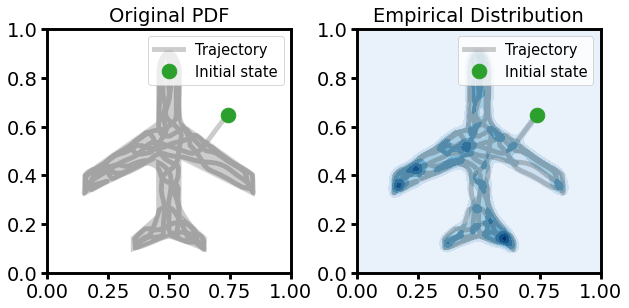

In [6]:
# visualize the trajectory
fig, axes = plt.subplots(1, 2, figsize=(9,5), dpi=70, tight_layout=True)

pdf_vals = pdf(grids)
ax = axes[0]
ax.set_aspect('equal')
ax.set_xlim(0.0, L_list[0])
ax.set_ylim(0.0, L_list[1])
ax.set_title('Original PDF')
if discrete_target:
    ax.imshow(target_img, extent=[0.0, 1.0, 0.0, 1.0], origin="lower", alpha=0.2)
else:
    ax.contourf(grids_x, grids_y, pdf_vals.reshape(grids_x.shape), cmap='Reds')
ax.plot(x_traj[::10,0], x_traj[::10,1], linestyle='-', marker='', color='k', alpha=0.2, label='Trajectory')
ax.plot(x_traj[0,0], x_traj[0,1], linestyle='', marker='o', markersize=15, color='C2', alpha=1.0, label='Initial state')
ax.legend(loc=1)

ax = axes[1]
ax.set_aspect('equal')
ax.set_xlim(0.0, L_list[0])
ax.set_ylim(0.0, L_list[1])
ax.set_title('Empirical Distribution')
ax.contourf(grids_x, grids_y, coverage_arr[-1,...].reshape(grids_x.shape), cmap='Blues')
ax.plot(x_traj[::10,0], x_traj[::10,1], linestyle='-', marker='', color='k', alpha=0.2, label='Trajectory')
ax.plot(x_traj[0,0], x_traj[0,1], linestyle='', marker='o', markersize=15, color='C2', alpha=1.0, label='Initial state')
ax.legend(loc=1)

plt.show()
plt.close()

In [7]:
import io
import base64
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def make_plotly_robot_slider(
    x_traj,
    *,
    discrete_target: bool,
    target_img=None,
    grids_x=None,
    grids_y=None,
    pdf_vals=None,
    downsample: int = 10,     # matches: t = int(frame * 10)
    trail_stride: int = 10,   # matches: x_traj[:t][::10]
    frame_duration_ms: int = 30,
    width: int = 800,
    height: int = 650,
    title: str = "Robot Trajectory (use slider or buttons)"
):
    x_traj = np.asarray(x_traj)
    assert x_traj.ndim == 2 and x_traj.shape[1] == 2, "x_traj must be shape (T,2)"
    T = x_traj.shape[0]
    assert T > 1, "x_traj needs more than one timestep."

    # Choose a nice color from Matplotlib palette
    traj_color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]

    def to_data_uri_from_mpl(fig_mpl):
        buf = io.BytesIO()
        fig_mpl.savefig(buf, format="png", bbox_inches="tight", pad_inches=0, dpi=200)
        plt.close(fig_mpl)
        return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

    # Build the background image
    if discrete_target:
        assert target_img is not None, "Provide target_img when discrete_target=True"
        # Flip vertically to mimic origin='lower'
        img = np.flipud(np.asarray(target_img))
        fig_bg, ax_bg = plt.subplots(figsize=(5.5, 5.5), dpi=150)
        ax_bg.imshow(img, extent=[0, 1, 0, 1], origin="upper", alpha=0.25)
        ax_bg.set_xlim(0, 1); ax_bg.set_ylim(0, 1); ax_bg.axis("off")
        img_uri = to_data_uri_from_mpl(fig_bg)
    else:
        assert (grids_x is not None) and (grids_y is not None) and (pdf_vals is not None), \
            "Provide grids_x, grids_y, pdf_vals when discrete_target=False"
        Z = np.asarray(pdf_vals)
        GX, GY = np.asarray(grids_x), np.asarray(grids_y)
        if Z.ndim == 1:
            Z = Z.reshape(GX.shape)
        fig_bg, ax_bg = plt.subplots(figsize=(5.5, 5.5), dpi=150)
        ax_bg.contourf(GX, GY, Z, cmap="Reds", levels=10)
        ax_bg.set_xlim(0, 1); ax_bg.set_ylim(0, 1); ax_bg.axis("off")
        img_uri = to_data_uri_from_mpl(fig_bg)

    # Figure and layout
    fig = go.Figure()
    fig.update_layout(
        images=[dict(
            source=img_uri,
            xref="x", yref="y",
            x=0, y=1,           # top-left anchor (so no extra transforms)
            sizex=1, sizey=1,
            sizing="stretch",
            layer="below"
        )],
        margin=dict(l=10, r=10, t=30, b=70),
        plot_bgcolor="white",
        width=width,
        height=height,
        title=title
    )

    # Trace 0: trail (starts empty to match your mpl animation)
    fig.add_trace(go.Scatter(
        x=[], y=[],
        mode="lines",
        line=dict(color=traj_color, width=4),
        showlegend=False
    ))

    # Trace 1: robot marker
    fig.add_trace(go.Scatter(
        x=[x_traj[0, 0]], y=[x_traj[0, 1]],
        mode="markers",
        marker=dict(size=12, color="black"),
        showlegend=False
    ))

    # Frames: update both trail and marker
    frames = []
    frame_indices = list(range(downsample, T, downsample))
    for i, t in enumerate(frame_indices):
        trail = x_traj[:t]
        if trail_stride > 1:
            trail = trail[::trail_stride]
        cur = x_traj[t]
        frames.append(go.Frame(
            name=str(i),
            data=[
                go.Scatter(x=trail[:, 0], y=trail[:, 1], mode="lines",
                           line=dict(color=traj_color, width=4)),
                go.Scatter(x=[cur[0]], y=[cur[1]], mode="markers",
                           marker=dict(size=12, color="black")),
            ],
            traces=[0, 1]
        ))
    fig.frames = frames

    # Slider
    steps = [
        dict(method="animate",
             args=[[str(i)], dict(mode="immediate",
                                  frame=dict(duration=0, redraw=True),
                                  transition=dict(duration=0))],
             label=str(i))
        for i in range(len(frames))
    ]
    fig.update_layout(
        sliders=[dict(
            active=0,
            y=-0.05,
            x=0.5,
            xanchor="center",
            pad=dict(t=10),
            len=0.6,
            steps=steps,
            currentvalue=dict(prefix="Step: ", font=dict(size=12))
        )]
    )

    # Buttons
    fig.update_layout(
        updatemenus=[dict(
            type="buttons",
            direction="left",
            x=0.5, y=-0.20,
            xanchor="center", yanchor="top",
            pad=dict(r=10, t=10),
            buttons=[
                dict(label="Start",
                     method="animate",
                     args=[None, dict(frame=dict(duration=frame_duration_ms, redraw=True),
                                      transition=dict(duration=0),
                                      fromcurrent=True,
                                      mode="immediate")]),
                dict(label="Pause",
                     method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        transition=dict(duration=0),
                                        mode="immediate")]),
                dict(label="Reset",
                     method="animate",
                     args=[[str(0)], dict(frame=dict(duration=0, redraw=True),
                                          transition=dict(duration=0),
                                          mode="immediate")]),
            ]
        )]
    )

    # Axes hidden, same [0,1] box with equal aspect
    fig.update_xaxes(visible=False, range=[0, 1], constrain="domain")
    fig.update_yaxes(visible=False, range=[0, 1], scaleanchor="x")
    return fig

# --- Usage ---
fig = make_plotly_robot_slider(
    x_traj=x_traj,
    discrete_target=discrete_target,
    target_img=target_img if discrete_target else None,
    grids_x=grids_x if not discrete_target else None,
    grids_y=grids_y if not discrete_target else None,
    pdf_vals=pdf_vals if not discrete_target else None,
    downsample=10,          # t = int(frame * 10)
    trail_stride=10,        # x_traj[:t][::10]
    frame_duration_ms=30
)
fig.show()


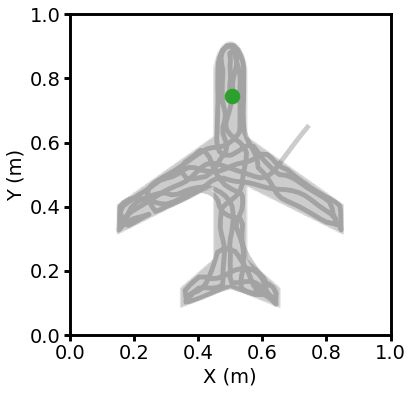

In [8]:
# Generate animation (takes about 1 minute)
from IPython.display import HTML
from matplotlib import animation

fig, ax = plt.subplots(1, 1, figsize=(6,7), dpi=70, tight_layout=True)
ax.set_aspect('equal')
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
if discrete_target:
    ax.imshow(target_img, extent=[0.0, 1.0, 0.0, 1.0], origin="lower", alpha=0.2)
else:
    ax.contourf(grids_x, grids_y, pdf_vals.reshape(grids_x.shape), cmap='Reds', levels=10)

robot_traj, = ax.plot([], [], linestyle='-', marker='', color='k', alpha=0.2)
robot_state, = ax.plot(x_traj[0,0], x_traj[0,1], linestyle='', marker='o', markersize=15, color='C2')

def update_plot(frame):
    t = int(frame * 10)
    robot_state.set_data(
        np.array([x_traj[t][0]]), np.array([x_traj[t][1]])
    )
    robot_traj.set_data(
        x_traj[:t,0][::10], x_traj[:t,1][::10]
    )

    return robot_state, robot_traj,

ani = animation.FuncAnimation(fig, update_plot, frames=int(tsteps/10)-1, blit=True, interval=30, repeat=False)
video = ani.to_html5_video()
HTML(video)